In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE  = '/content/drive/MyDrive/reconocimiento_facial_tec_culiacan'
AUG   = f'{BASE}/dataset/augmented'
FACES = f'{BASE}/dataset/faces'
MODEL = f'{BASE}/modelo'

os.makedirs(MODEL, exist_ok=True)

print(' Drive montado')
print(f' Fases  : {FACES}')
print(f' Modelo : {MODEL}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive montado
📁 Faces  : /content/drive/MyDrive/reconocimiento_facial_tec_culiacan/dataset/faces
📁 Modelo : /content/drive/MyDrive/reconocimiento_facial_tec_culiacan/modelo


In [ ]:
!pip install -q ultralytics==8.2.0

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f' La que tenemoss GPU activa: {gpus[0].name}')
else:
    print(' lasrimozamente No hay GPU — ve a Entorno de ejecución → Cambiar tipo → T4 GPU')

print(f'✅ TensorFlow {tf.__version__}')

✅ GPU activa: /physical_device:GPU:0
✅ TensorFlow 2.20.0


In [ ]:
# Las imágenes ya están en Drive/dataset/faces desde la sesión anterior
# Las copiamos a memoria local para que el entrenamiento sea rápido
# (trabajar directo en Drive es muy lento)

import shutil
import os

FACES_LOCAL     = '/content/faces_local'
PROCESSED_LOCAL = '/content/processed_local'

if os.path.exists(FACES_LOCAL):
    shutil.rmtree(FACES_LOCAL)

print(' Copiando imágenes de Drive a memoria local...')
print('   Esto tarda ~2-3 minutos (una sola vez)')

shutil.copytree(FACES, FACES_LOCAL)

total = sum(
    len(files)
    for _, _, files in os.walk(FACES_LOCAL)
)

print(f'Copia completada')
print(f'   Total imágenes en memoria local: {total}')
print(f'   Clases encontradas: {len(os.listdir(FACES_LOCAL))}')

🔄 Copiando imágenes de Drive a memoria local...
   Esto tarda ~2-3 minutos (una sola vez)
✅ Copia completada
   Total imágenes en memoria local: 4000
   Clases encontradas: 20


In [ ]:
import shutil
import random
import os

TRAIN = f'{PROCESSED_LOCAL}/train'
VAL   = f'{PROCESSED_LOCAL}/val'
TEST  = f'{PROCESSED_LOCAL}/test'

for split in [TRAIN, VAL, TEST]:
    os.makedirs(split, exist_ok=True)

random.seed(42)

print('🔄 Dividiendo dataset...\n')

for clase in sorted(os.listdir(FACES_LOCAL)):
    carpeta = f'{FACES_LOCAL}/{clase}'
    imagenes = [f for f in os.listdir(carpeta) if f.endswith('.jpeg')]
    random.shuffle(imagenes)

    n       = len(imagenes)
    n_train = int(n * 0.70)
    n_val   = int(n * 0.15)

    splits = {
        TRAIN: imagenes[:n_train],
        VAL:   imagenes[n_train:n_train + n_val],
        TEST:  imagenes[n_train + n_val:],
    }

    for destino, archivos in splits.items():
        carpeta_dest = f'{destino}/{clase}'
        os.makedirs(carpeta_dest, exist_ok=True)
        for archivo in archivos:
            shutil.copy(f'{carpeta}/{archivo}', f'{carpeta_dest}/{archivo}')

    print(f'  {clase:<25} train={len(splits[TRAIN])}  val={len(splits[VAL])}  test={len(splits[TEST])}')

print(f'\nSplit completado')

🔄 Dividiendo dataset...

   ✅ Bryan_Najera              train=140  val=30  test=30
   ✅ Carlos_Angulo             train=140  val=30  test=30
   ✅ Carlos_Padilla            train=140  val=30  test=30
   ✅ Denzel_Gutierrez          train=140  val=30  test=30
   ✅ Edgar_Beltran             train=140  val=30  test=30
   ✅ Edgar_Cervantes           train=140  val=30  test=30
   ✅ Edwin_Dominguez           train=140  val=30  test=30
   ✅ Emilio_Ruiz               train=140  val=30  test=30
   ✅ Giovanni_Gonzalez         train=140  val=30  test=30
   ✅ Javier_Murillo            train=140  val=30  test=30
   ✅ Jeylen_Garcia             train=140  val=30  test=30
   ✅ Jorge_Lara                train=140  val=30  test=30
   ✅ Jose_Ozuna                train=140  val=30  test=30
   ✅ Jose_Sotelo               train=140  val=30  test=30
   ✅ Juan_Madrid               train=140  val=30  test=30
   ✅ Juan_Quiñonez            train=140  val=30  test=30
   ✅ Luis_Sanchez              train=140  val=3

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(rescale=1./255)
val_gen   = ImageDataGenerator(rescale=1./255)
test_gen  = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    TRAIN,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_data = val_gen.flow_from_directory(
    VAL,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_data = test_gen.flow_from_directory(
    TEST,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print(f'Generadores listos')
print(f'   Clases detectadas : {train_data.num_classes}')
print(f'   Imágenes train    : {train_data.samples}')
print(f'   Imágenes val      : {val_data.samples}')
print(f'   Imágenes test     : {test_data.samples}')
print(f'\n   Mapa de clases:')
for nombre, idx in sorted(train_data.class_indices.items(), key=lambda x: x[1]):
    print(f'     {idx:>2} → {nombre}')

Found 2800 images belonging to 20 classes.
Found 600 images belonging to 20 classes.
Found 600 images belonging to 20 classes.
✅ Generadores listos
   Clases detectadas : 20
   Imágenes train    : 2800
   Imágenes val      : 600
   Imágenes test     : 600

   Mapa de clases:
      0 → Bryan_Najera
      1 → Carlos_Angulo
      2 → Carlos_Padilla
      3 → Denzel_Gutierrez
      4 → Edgar_Beltran
      5 → Edgar_Cervantes
      6 → Edwin_Dominguez
      7 → Emilio_Ruiz
      8 → Giovanni_Gonzalez
      9 → Javier_Murillo
     10 → Jeylen_Garcia
     11 → Jorge_Lara
     12 → Jose_Ozuna
     13 → Jose_Sotelo
     14 → Juan_Madrid
     15 → Juan_Quiñonez
     16 → Luis_Sanchez
     17 → Marcelo_Vidrio
     18 → Marian_Ramirez
     19 → Yahir_Ortega


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

base = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base.trainable = False

x = base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
output = layers.Dense(20, activation='softmax')(x)

model = Model(inputs=base.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

total_params   = model.count_params()
entrenables    = sum([tf.size(w).numpy() for w in model.trainable_weights])
no_entrenables = total_params - entrenables

print('ya conseguimoss el Modelo construido')
print(f'   Parámetros totales     : {total_params:,}')
print(f'   Parámetros entrenables : {entrenables:,}  ← solo estos se actualizan')
print(f'   Parámetros congelados  : {no_entrenables:,} ← conocimiento de ImageNet')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ Modelo construido
   Parámetros totales     : 2,621,396
   Parámetros entrenables : 363,412  ← solo estos se actualizan
   Parámetros congelados  : 2,257,984 ← conocimiento de ImageNet


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Guarda el mejor modelo en memoria local durante el entrenamiento
checkpoint = ModelCheckpoint(
    filepath='/content/mejor_modelo.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print('🔄 Iniciando entrenamiento...')
print('   Epochs máx   : 25')
print('   Batch size   : 32')
print('   Learning rate: 0.0001\n')

history = model.fit(
    train_data,
    epochs=25,
    validation_data=val_data,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print('\n Entrenamiento completado')
print(f'   Mejor val_accuracy: {max(history.history["val_accuracy"]):.4f}')

🔄 Iniciando entrenamiento...
   Epochs máx   : 25
   Batch size   : 32
   Learning rate: 0.0001

Epoch 1/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.1174 - loss: 3.0137
Epoch 1: val_accuracy improved from None to 0.60833, saving model to /content/mejor_modelo.keras

Epoch 1: finished saving model to /content/mejor_modelo.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 58s 431ms/step - accuracy: 0.2118 - loss: 2.7317 - val_accuracy: 0.6083 - val_loss: 2.0909
Epoch 2/25
87/88 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5011 - loss: 2.0042
Epoch 2: val_accuracy improved from 0.60833 to 0.79667, saving model to /content/mejor_modelo.keras

Epoch 2: finished saving model to /content/mejor_modelo.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.5461 - loss: 1.8251 - val_accuracy: 0.7967 - val_loss: 1.2582
Epoch 3/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7020 - loss: 1.3119
Epoch 3: val_accuracy improved from 0.79667 to 0.86500, saving model to /content/mejor_mod

📊 Resultados en datos de prueba:
   Accuracy : 95.67%
   Loss     : 0.1671


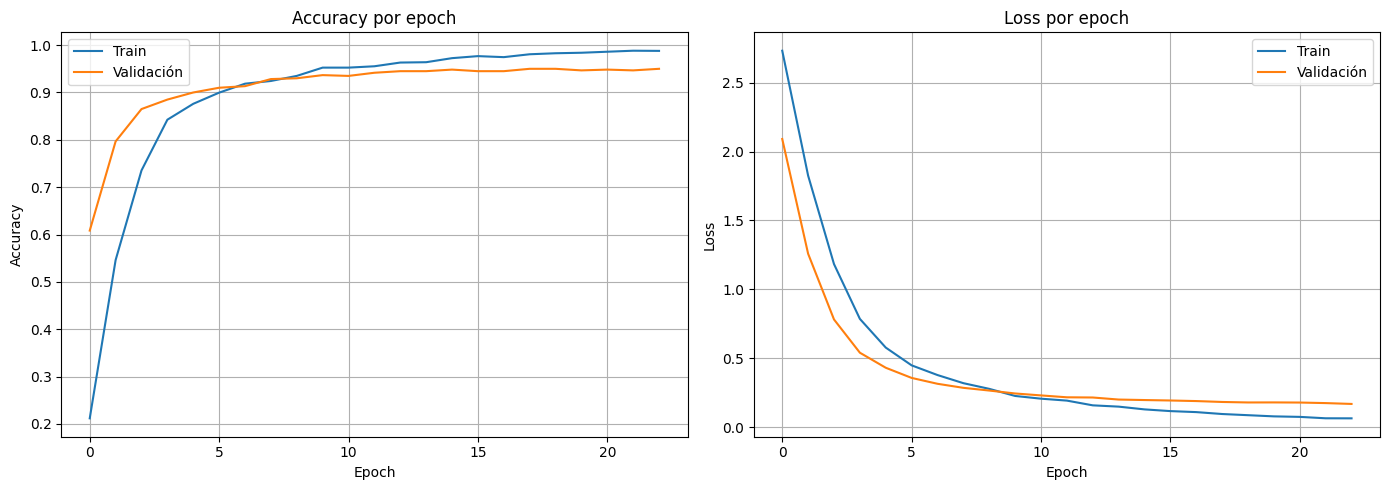

✅ Gráfica generada


In [ ]:
import matplotlib.pyplot as plt

loss, accuracy = model.evaluate(test_data, verbose=0)
print(f'Resultados en datos de prueba:')
print(f'   Accuracy : {accuracy*100:.2f}%')
print(f'   Loss     : {loss:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Validación')
ax1.set_title('Accuracy por epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Validación')
ax2.set_title('Loss por epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('/content/curvas_entrenamiento.png', dpi=150)
plt.show()


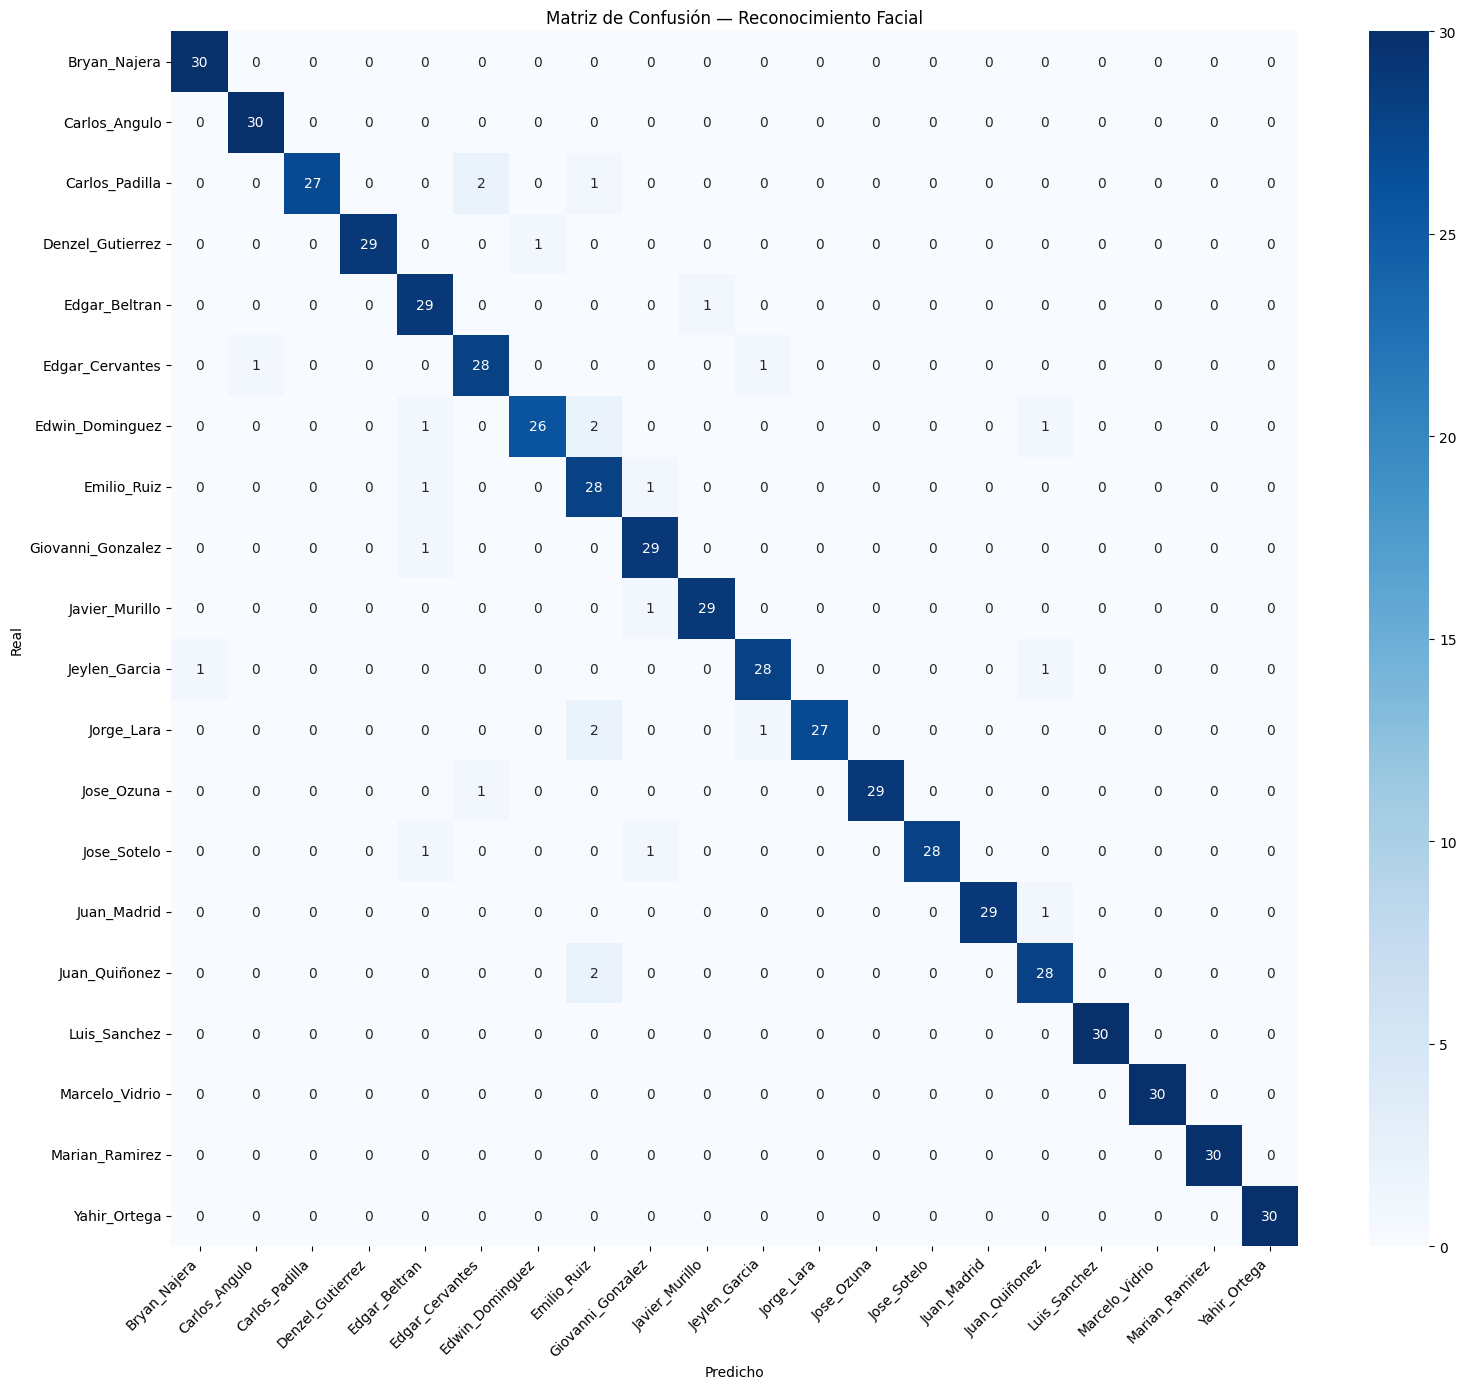


📊 Reporte por alumno:
                   precision    recall  f1-score   support

     Bryan_Najera       0.97      1.00      0.98        30
    Carlos_Angulo       0.97      1.00      0.98        30
   Carlos_Padilla       1.00      0.90      0.95        30
 Denzel_Gutierrez       1.00      0.97      0.98        30
    Edgar_Beltran       0.88      0.97      0.92        30
  Edgar_Cervantes       0.90      0.93      0.92        30
  Edwin_Dominguez       0.96      0.87      0.91        30
      Emilio_Ruiz       0.80      0.93      0.86        30
Giovanni_Gonzalez       0.91      0.97      0.94        30
   Javier_Murillo       0.97      0.97      0.97        30
    Jeylen_Garcia       0.93      0.93      0.93        30
       Jorge_Lara       1.00      0.90      0.95        30
       Jose_Ozuna       1.00      0.97      0.98        30
      Jose_Sotelo       1.00      0.93      0.97        30
      Juan_Madrid       1.00      0.97      0.98        30
   Juan_Quiñonez       0.90    

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

y_pred_probs = model.predict(test_data, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_data.classes

nombres_clases = list(test_data.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=nombres_clases,
    yticklabels=nombres_clases
)
plt.title('Matriz de Confusión — Reconocimiento Facial')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/matriz_confusion.png', dpi=150)
plt.show()

print('\n Reporte por alumno:')
print(classification_report(y_true, y_pred, target_names=nombres_clases))

In [ ]:
import shutil
import json
import os

print('Proseso donde vamos guardando modelos y métricas en Drive...')

# Modelo Keras y TFLite
model.save(f'{MODEL}/modelo_facial.keras')

converter    = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open(f'{MODEL}/modelo_facial.tflite', 'wb') as f:
    f.write(tflite_model)

# Mapa de clases para la app
class_map = {str(v): k for k, v in train_data.class_indices.items()}
with open(f'{BASE}/app_data/class_map.json', 'w') as f:
    json.dump(class_map, f, ensure_ascii=False, indent=2)

# Métricas
shutil.copy('/content/curvas_entrenamiento.png', f'{BASE}/metricas/curvas_entrenamiento.png')
shutil.copy('/content/matriz_confusion.png',     f'{BASE}/metricas/matriz_confusion.png')

# Tamaños
size_keras  = os.path.getsize(f'{MODEL}/modelo_facial.keras')  / 1024 / 1024
size_tflite = os.path.getsize(f'{MODEL}/modelo_facial.tflite') / 1024 / 1024

print(' Todo guardado en Drive:')
print(f'   modelo_facial.keras   : {size_keras:.1f} MB')
print(f'   modelo_facial.tflite  : {size_tflite:.1f} MB')
print(f'   class_map.json        : app_data/')
print(f'   curvas_entrenamiento  : metricas/')
print(f'   matriz_confusion      : metricas/')

🔄 Guardando modelos y métricas en Drive...
Saved artifact at '/tmp/tmpxvvao05w'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 20), dtype=tf.float32, name=None)
Captures:
  138851462791248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138851462793744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138851462796432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138851462796048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138851462794896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138851462796624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138851462795088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138851462797200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138851462796816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138851462794704: TensorSpec(shape=(), dt